In [1]:
## 1. Data Pull
#In this notebook, I begin the project by pulling historical market data for the initial stock universe and the benchmark (SPY). 
#At this stage, my goal is not to build the model yet, but to establish a clean and reproducible price data pipeline that I can use later for factor construction, portfolio formation, and backtesting.

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
## 2. Define project paths relative to the notebook location
project_root = Path.cwd().parent
raw_data_path = project_root / "data" / "raw"
print ("Project root:", project_root)
print ("Raw data path", raw_data_path)

Project root: /Users/AnyiXu_1/Desktop/multi-factor-equity-alpha-model
Raw data path /Users/AnyiXu_1/Desktop/multi-factor-equity-alpha-model/data/raw


In [4]:
## 3. Define stock universe
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "BRK-B", "JPM", "V", "MA",
    "UNH", "HD", "PG", "XOM", "CVX", "LLY", "ABBV", "PEP", "KO", "COST",
    "MRK", "AVGO", "WMT", "BAC", "ADBE", "CRM", "NFLX", "MCD", "TMO", "ACN"]
benchmark = "SPY"
all_tickers = tickers + [benchmark]
print (f"Number of stocks in initial universe: {len(tickers)}")
print (f"Benchmark: {benchmark}")
print (f"Total tickers to pull: {len(all_tickers)}")

Number of stocks in initial universe: 30
Benchmark: SPY
Total tickers to pull: 31


In [5]:
## 4. Save ticker list
ticker_df = pd.DataFrame({"tickers": tickers, "role": "stock"})
benchmark_df = pd.DataFrame ({"tickers": [benchmark], "role": ["benchmark"]})
ticker_master = pd.concat([ticker_df, benchmark_df], ignore_index=True)
ticker_master.to_csv(raw_data_path / "tickers.csv", index=False)
ticker_master.head()

,tickers,role
0,AAPL,stock
1,MSFT,stock
2,AMZN,stock
3,GOOGL,stock
4,META,stock


In [6]:
## 5. Download historical prices
start_date = "2018-01-01"
end_date = None
price_data = yf.download(tickers=all_tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)
price_data.head()

Price           Close                                                \
Ticker           AAPL       ABBV         ACN        ADBE       AMZN   
Date                                                                  
2018-01-02  40.304173  69.343719  135.558258  177.699997  59.450500   
2018-01-03  40.297161  70.428848  136.183853  181.039993  60.209999   
2018-01-04  40.484329  70.027191  137.796402  183.220001  60.479500   
2018-01-05  40.945259  71.246223  138.933090  185.339996  61.457001   
2018-01-08  40.793179  70.104713  140.043381  185.039993  62.343498   

Price                                                                 ...  \
Ticker           AVGO        BAC       BRK-B        COST         CRM  ...   
Date                                                                  ...   
2018-01-02  21.086662  24.637497  197.220001  168.498184  102.899277  ...   
2018-01-03  21.317259  24.555096  199.789993  170.520294  103.766556  ...   
2018-01-04  21.324375  24.876453  200.690002  169.196091  105.136429  ...   
2018-01-05  21.450729  24.991814  201.419998  167.988129  106.535881  ...   
2018-01-08  21.502064  24.818777  202.740005  168.641266  107.284882  ...   

Price          Volume                                                  \
Ticker           NFLX       NVDA      PEP       PG       SPY      TMO   
Date                                                                    
2018-01-02  109669000  355616000  4165800  7558900  86655700  1140900   
2018-01-03   85914000  914704000  4224000  5863600  90070400  1458300   
2018-01-04   60296000  583268000  3147000  6322500  80636400  1566400   
2018-01-05   70332000  580124000  2714200  5949700  83524000  1469500   
2018-01-08   55802000  881216000  5730400  4860700  57319200  1974600   

Price                                             
Ticker          UNH        V       WMT       XOM  
Date                                              
2018-01-02  3485000  6080900  30451500  11469300  
2018-01-03  2417600  6946100  26710800  13957700  
2018-01-04  2749100  7805300  20491200  10863000  
2018-01-05  2432800  8590500  21852000  11047600  
2018-01-08  2850800  6660700  26531700  10927100  

[5 rows x 155 columns]

In [7]:
## 6. Exract adjusted close prices
close_prices = price_data["Close"].copy()
close_prices.index = pd.to_datetime(close_prices.index)
close_prices = close_prices.sort_index()
print("Close prices data shape:", close_prices.shape)
close_prices.head()

Close prices data shape: (2080, 31)


Ticker,AAPL,ABBV,ACN,ADBE,AMZN,AVGO,BAC,BRK-B,COST,CRM,...,NFLX,NVDA,PEP,PG,SPY,TMO,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.304173,69.343719,135.558258,177.699997,59.450500,21.086662,24.637497,197.220001,168.498184,102.899277,...,20.107000,4.928266,91.602791,72.824966,236.562180,188.755325,193.090485,108.111916,28.855198,58.580421
2018-01-03,40.297161,70.428848,136.183853,181.039993,60.209999,21.317259,24.555096,199.789993,170.520294,103.766556,...,20.504999,5.252614,91.362274,72.736610,238.058411,192.217896,195.116028,109.188217,29.106909,59.730961
2018-01-04,40.484329,70.027191,137.796402,183.220001,60.479500,21.324375,24.876453,200.690002,169.196091,105.136429,...,20.563000,5.280302,91.812271,73.250755,239.061844,194.623993,195.962891,109.594200,29.133242,59.813622
2018-01-05,40.945259,71.246223,138.933090,185.339996,61.457001,21.450729,24.991814,201.419998,167.988129,106.535881,...,20.999001,5.325049,92.076096,73.298973,240.654938,197.959396,199.699692,112.218857,29.305925,59.765404
2018-01-08,40.793179,70.104713,140.043381,185.039993,62.343498,21.502064,24.818777,202.740005,168.641266,107.284882,...,21.205000,5.488214,91.548485,73.684570,241.095032,198.282120,196.233566,112.672028,29.739092,60.034073


In [8]:
## 7. Check and ffill/bfill missing data
missing_data_summary = close_prices.isna().sum().sort_values(ascending=False)
print("Missing before fill:", close_prices.isna().sum().sum())
close_prices = close_prices.ffill().bfill()
print("Missing after fill:", close_prices.isna().sum().sum())

Missing before fill: 0
Missing after fill: 0


In [9]:
close_prices.to_csv(raw_data_path / "prices.csv")
print("Save files:")
print("-", raw_data_path/ "tickers.csv")
print("-", raw_data_path/ "prices.csv")

Save files:
- /Users/AnyiXu_1/Desktop/multi-factor-equity-alpha-model/data/raw/tickers.csv
- /Users/AnyiXu_1/Desktop/multi-factor-equity-alpha-model/data/raw/prices.csv


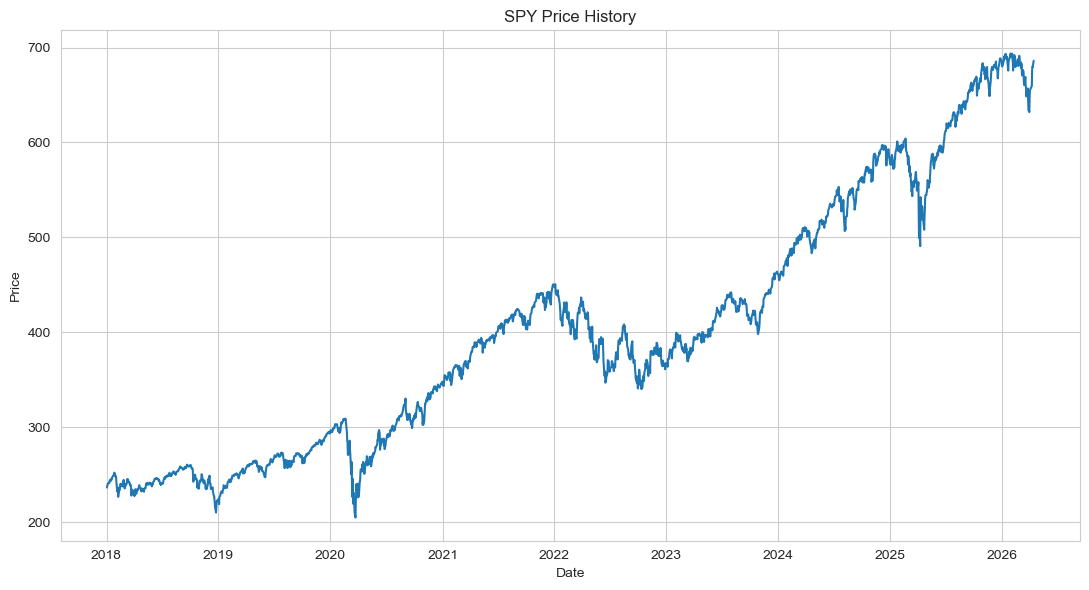

In [10]:
## 8. Exploratory Data Analysis (EDA)
sns.set_style("whitegrid")
plt.figure(figsize=(11,6))
sns.lineplot(data=close_prices, x=close_prices.index, y=benchmark)
plt.title("SPY Price History")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

In [11]:
daily_returns = close_prices.pct_change()
daily_returns [[benchmark]].head()

Ticker,SPY
Date,
2018-01-02,NaN
2018-01-03,0.006325
2018-01-04,0.004215
2018-01-05,0.006664
2018-01-08,0.001829


In [12]:
## Conclusion:
#The first pass of the data pipeline is now in place. I have defined an initial stock universe, included SPY as the benchmark, downloaded historical price data, and stored the raw files for later stages of the project.
#The next step will be to review data quality more carefully, handle any missing values, and prepare the price series for return calculations and factor construction.